### `NicheCompass` analysis of Visium HD Spatial Gene Expression Library of Human Colorectal Cancer (FFPE)
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Creation date:** 7th of November 2024
- **Last modified date:** 7th of November 2024

This notebooks performes the `NicheCompass` analysis on Human Colorectal Cancer dataset downloaded from 10X Genomics. 
Prior this analysis:
* The dataset was transormed to anndata object.
* Filtered using the parameters `sc.pp.filter_cells(adata, min_counts=1)` and `sc.pp.filter_genes(adata, min_cells=3)`
* Spots belonging to the same cells were allocated together with `bin2cell`

+ Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import warnings
from datetime import datetime
import json

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
from matplotlib import gridspec
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import anndata as ad

import torch
from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                create_new_color_dict,
                                extract_gp_dict_from_mebocost_es_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps,
                                generate_enriched_gp_info_plots)

In [3]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

#### Define Parameters

In [4]:
### Dataset ###
dataset = "colorectal cancer"
species = "human"
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData Keys
counts_key = "counts"
adj_key = "spatial_connectivities"
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 400
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # increase if gene selection desired
lambda_l1_addon = 100.
edge_batch_size = 1024 # increase if more memory available
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "leiden"
latent_leiden_resolution = 0.4
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "Donor_ID"
spot_size = 0.2
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

#### Run Notebook Setup

In [5]:
warnings.filterwarnings("ignore")

In [6]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

#### Configure Paths

In [7]:
# Define paths
ga_data_folder_path = "data10X_Xenium_data/NicheCompass/gene_annotations"
gp_data_folder_path = "data10X_Xenium_data/NicheCompass/gene_programs"
so_data_folder_path = "data/VisiumHD_CRC/NicheCompass/spatial_omics"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"
artifacts_folder_path = f"data/VisiumHD_CRC/NicheCompass/artifacts"
model_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/model"
figure_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/figures"

#### Create Directories

In [8]:
import os
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(so_data_folder_path, exist_ok=True)

#### Upload the anndata file

In [9]:
adata = sc.read_h5ad("data/VisiumHD_CRC/NicheCompass_hs_VisiumHD_CRC_NC_AM_08112024_095742_raw.h5ad")

In [10]:
adata

AnnData object with n_obs × n_vars = 257215 × 18058
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'Donor_ID', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'processing_history', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Prepare Model Training

+ Create Prior Knowledge Gene Program (GP) Mask

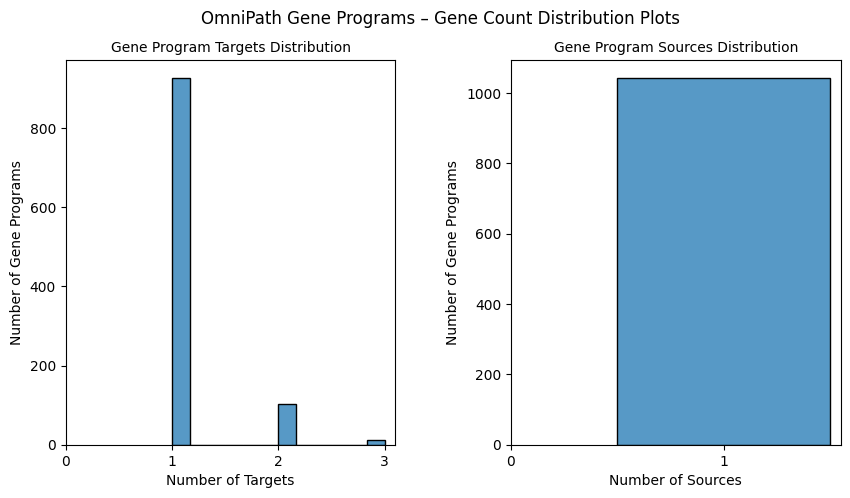

In [11]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    min_curation_effort=0,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.svg")

In [12]:
# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

COMPLEX:GAD2_SLC6A13_ligand_receptor_GP: {'sources': ['COMPLEX:GAD2_SLC6A13'], 'targets': ['GABBR2'], 'sources_categories': ['ligand'], 'targets_categories': ['receptor']}


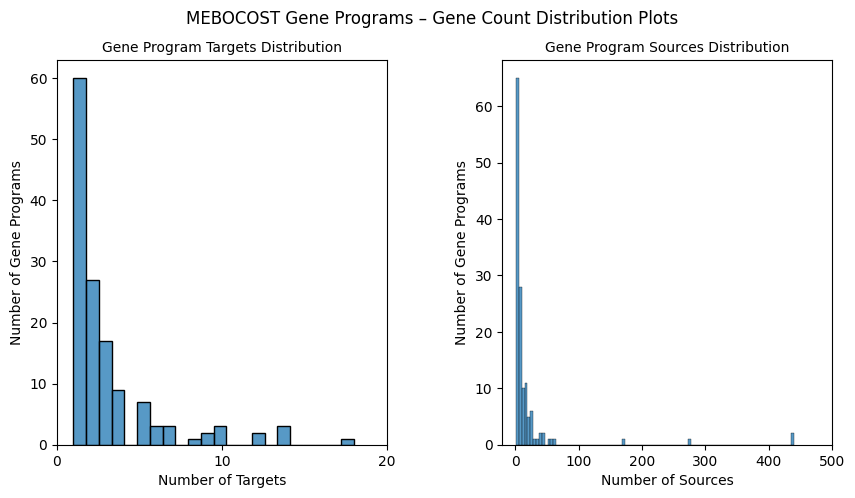

In [13]:
# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_es_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

In [14]:
# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

11-cis-Retinol_metabolite_enzyme_sensor_GP: {'sources': ['DGAT1', 'LRAT', 'RPE65'], 'sources_categories': ['enzyme', 'enzyme', 'enzyme'], 'targets': ['NR2F2'], 'targets_categories': ['sensor']}


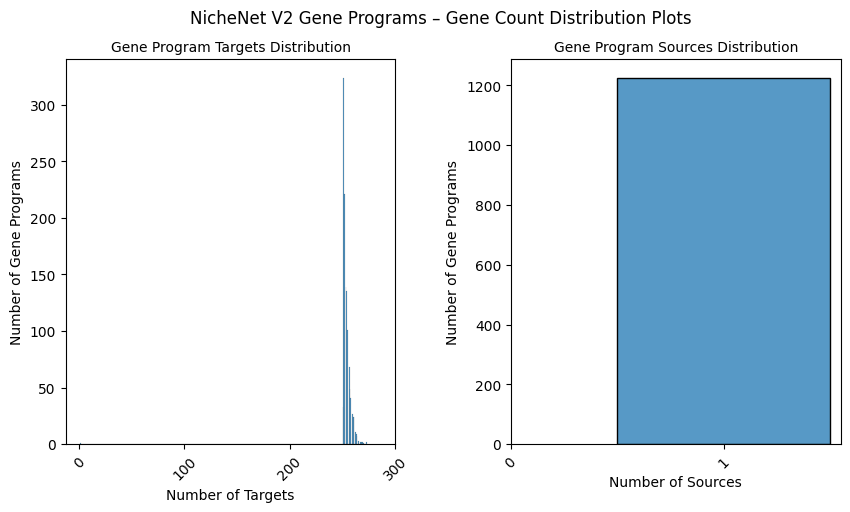

In [15]:
# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

In [16]:
# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

PVR_ligand_receptor_target_gene_GP: {'sources': ['PVR'], 'targets': ['CD226', 'TIGIT', 'CD96', 'PVRIG', 'NECTIN3', 'KIR2DL5A', 'NECTIN4', 'A2M', 'ADM', 'AHNAK', 'ANKRD1', 'APP', 'AR', 'ARID5B', 'ASS1', 'ATF3', 'BAMBI', 'BAX', 'BCL2', 'BCL2L1', 'BCL2L11', 'BCL3', 'BCL6', 'BDNF', 'BHLHE40', 'BIRC3', 'BIRC5', 'BMP4', 'BRCA1', 'BTG1', 'BTG2', 'C3', 'CA2', 'CAV1', 'CBX5', 'CCL2', 'CCL20', 'CCL5', 'CCN1', 'CCN2', 'CCNA2', 'CCNB1', 'CCND1', 'CCND2', 'CCND3', 'CD14', 'CD44', 'CD5L', 'CDH1', 'CDK4', 'CDK6', 'CDKN1A', 'CDKN1B', 'CDKN2C', 'CEACAM1', 'CEBPA', 'CEBPB', 'CITED2', 'CKS1B', 'CLDN1', 'COL1A2', 'CRABP2', 'CSF2', 'CXADR', 'CXCL1', 'CXCL2', 'CXCL8', 'CXCR4', 'CYP1A1', 'CYP1B1', 'DDIT3', 'DDIT4', 'DHRS3', 'DKK1', 'DNMT1', 'DTL', 'DUSP1', 'DUSP10', 'DUSP4', 'DUSP5', 'DUSP6', 'E2F1', 'EBI3', 'EDN1', 'EFNA1', 'EGFR', 'EGR1', 'EGR2', 'EGR3', 'ELF3', 'EMP1', 'EPAS1', 'EPHA2', 'ESR1', 'ETFB', 'ETS1', 'F3', 'FAS', 'FASN', 'FN1', 'FOS', 'FOSL1', 'FOSL2', 'FOXA1', 'FOXO3', 'FST', 'GADD45A', 'GADD45

In [17]:
# Add GPs into one combined dictionary for model training
combined_gp_dict = dict(omnipath_gp_dict)
combined_gp_dict.update(mebocost_gp_dict)
combined_gp_dict.update(nichenet_gp_dict)

In [18]:
# Filter and combine GPs to avoid overlaps
combined_new_gp_dict = filter_and_combine_gp_dict_gps(
    gp_dict=combined_gp_dict,
    gp_filter_mode="subset",
    combine_overlap_gps=True,
    overlap_thresh_source_genes=0.9,
    overlap_thresh_target_genes=0.9,
    overlap_thresh_genes=0.9)

print("Number of gene programs before filtering and combining: "
      f"{len(combined_gp_dict)}.")
print(f"Number of gene programs after filtering and combining: "
      f"{len(combined_new_gp_dict)}.")

Number of gene programs before filtering and combining: 2406.
Number of gene programs after filtering and combining: 1987.


#### Compute Spatial Neighbor Graph for adata

In [39]:
# Compute spatial neighborhood
sq.gr.spatial_neighbors(adata,
                        coord_type="generic",
                        spatial_key=spatial_key,
                        n_neighs=n_neighbors)

# Make adjacency matrix symmetric
adata.obsp[adj_key] = (
    adata.obsp[adj_key].maximum(
        adata.obsp[adj_key].T))

+ Add GP Mask to Data

In [38]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_new_gp_dict,
    adata=adata,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

+ Explore Data

In [40]:
cell_type_colors = create_new_color_dict(
    adata=adata,
    cat_key=cell_type_key)

In [41]:
print(f"Number of nodes (observations): {adata.layers['counts'].shape[0]}")
print(f"Number of node features (genes): {adata.layers['counts'].shape[1]}")

Number of nodes (observations): 257215
Number of node features (genes): 18058


#### Train Model

+ Initialize, Train & Save Model

In [23]:
torch.cuda.set_device(1)

In [34]:
adata = sc.read_h5ad("data/VisiumHD_CRC/NicheCompass_hs_VisiumHD_CRC_NC_AM_08112024_095742_raw.h5ad")

In [36]:
adata_raw = adata.copy()

In [42]:
model = NicheCompass(adata,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 18058, n_cat_covariates_embed_input: 0, n_hidden: 1821, n_latent: 1721, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1721, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 18058
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1721, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 18058


* Train model

In [ ]:
def convert_adata_to_float32(adata):
    # Convert main matrix
    if isinstance(adata.X, np.ndarray):
        adata.X = adata.X.astype(np.float32)
    else:
        adata.X = adata.X.toarray().astype(np.float32)
    
    # Convert layers if they exist
    for key in adata.layers.keys():
        if isinstance(adata.layers[key], np.ndarray):
            adata.layers[key] = adata.layers[key].astype(np.float32)
        else:
            adata.layers[key] = adata.layers[key].toarray().astype(np.float32)
    
    # Convert obsm matrices if they exist
    for key in adata.obsm.keys():
        if isinstance(adata.obsm[key], np.ndarray):
            adata.obsm[key] = adata.obsm[key].astype(np.float32)
    
    return adata

In [43]:
adata = convert_adata_to_float32(adata)

In [44]:
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            latent_dtype=np.float32,
            verbose=True)


--- INITIALIZING TRAINER ---
Number of training nodes: 231493
Number of validation nodes: 25722
Number of training edges: 545781
Number of validation edges: 60642
Edge batch size: 1024
Node batch size: None

--- MODEL TRAINING ---
Epoch 1/400 |--------------------| 0.2% val_auroc_score: 0.9613; val_auprc_score: 0.9546; val_best_acc_score: 0.8980; val_best_f1_score: 0.9011; train_kl_reg_loss: 23883.4980; train_edge_recon_loss: 294772.8367; train_gene_expr_recon_loss: 2090771.1970; train_masked_gp_l1_reg_loss: 0.0000; train_group_lasso_reg_loss: 0.0000; train_addon_gp_l1_reg_loss: 0.0000; train_global_loss: 2409427.5249; train_optim_loss: 2409427.5249; val_kl_reg_loss: 21434.6135; val_edge_recon_loss: 283477.1651; val_gene_expr_recon_loss: 1994499.1687; val_masked_gp_l1_reg_loss: 0.0000; val_group_lasso_reg_loss: 0.0000; val_addon_gp_l1_reg_loss: 0.0000; val_global_loss: 2299410.9500; val_optim_loss: 2299410.9500
Epoch 2/400 |--------------------| 0.5% val_auroc_score: 0.9745; val_auprc

+ Compute UMAP

In [45]:
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

sc.tl.umap(model.adata,
           neighbors_key=latent_key)

2024-11-08 13:35:06.083793: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 13:35:06.105490: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-08 13:35:06.105527: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-08 13:35:06.105561: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-08 13:35:06.111214: I tensorflow/core/platform/cpu_feature_g

* Save trained model

In [46]:
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")

#### Visualize NicheCompass Latent GP Space

In [47]:
cell_type_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=cell_type_key)

In [48]:
# Create plot of cell type annotations in physical and latent space
groups = None
save_fig = True
samples = model.adata.obs[sample_key].unique().tolist()
file_path = f"{figure_folder_path}/" \
            "cell_types_latent_physical_space.png"

fig = plt.figure(figsize=(12, 14), dpi=300)
title = fig.suptitle(t=f"Cell Types " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata, 
           color=[cell_type_key],
           groups=groups,palette=cell_type_colors,
           title=f"Cell Types in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sq.pl.spatial_scatter(adata, 
              library_id="spatial", 
              shape=None,
              color=[cell_type_key],
              size=0.2,
              title=f"Cell Types in Physical Space \n"
                    f"(Sample: {sample})",
              legend_loc=None, 
              frameon=False,
              ax=axs[idx+1], 
              alpha=1.0)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

#### 4.2 Identify Niches

+ Compute latent Leiden clustering

In [49]:
sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)

In [50]:
latent_cluster_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=latent_cluster_key)

In [51]:
adata = model.adata.copy()

In [52]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["17"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.png"

fig = plt.figure(figsize=(12, 14), dpi = 300)
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[latent_cluster_key],
           groups=groups,
           palette=latent_cluster_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sq.pl.spatial_scatter(adata,
                          library_id="spatial",
                          shape=None,
                          color=[latent_cluster_key],
                          size=0.2,
                          title=f"Niches in Physical Space \n"
                              f"(Sample: {sample})",
                          legend_loc=None,
                          frameon=False,
                          ax=axs[idx+1])

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

#### 4.3 Characterize Niches

+ 4.3.1 Niche Composition

In [54]:
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            f"niche_composition.png"

df_counts = (model.adata.obs.groupby([latent_cluster_key, cell_type_key])
             .size().unstack())
df_counts.plot(kind="bar", stacked=True, figsize=(10, 10))
legend = plt.legend(bbox_to_anchor=(1, 1), loc="upper left", prop={'size': 10})
legend.set_title("Cell Type Annotations", prop={'size': 10})
plt.title("Cell Type Composition of Niches")
plt.xlabel("Niche")
plt.ylabel("Cell Counts")
if save_fig:
    plt.savefig(file_path,
                bbox_extra_artists=(legend,),
                bbox_inches="tight",
                dpi=300)  

In [55]:
df_counts.to_csv(f"{figure_folder_path}/niche_composition.csv")

+ 4.3.2 Differential GPs

In [56]:
# Check number of active GPs
active_gps = model.get_active_gps()
print(f"Number of total gene programs: {len(model.adata.uns[gp_names_key])}.")
print(f"Number of active gene programs: {len(active_gps)}.")

Number of total gene programs: 1821.
Number of active gene programs: 1752.


In [57]:
# Display example active GPs
gp_summary_df = model.get_gp_summary()
gp_summary_df[gp_summary_df["gp_active"] == True].head()

,gp_name,all_gp_idx,gp_active,active_gp_idx,n_source_genes,n_non_zero_source_genes,n_target_genes,n_non_zero_target_genes,gp_source_genes,gp_target_genes,gp_source_genes_weights,gp_target_genes_weights,gp_source_genes_importances,gp_target_genes_importances
0,FYN_ligand_receptor_GP,0,True,0,1,1,1,1,[FYN],[PIK3CD],[1.1165],[0.8277],[0.5743],[0.4257]
1,S100A10_ligand_receptor_GP,1,True,1,1,1,1,1,[S100A10],[PLA2G4A],[0.7948],[-0.043],[0.9486],[0.0514]
2,IGF1_ligand_receptor_GP,2,True,2,1,1,1,1,[IGF1],[SOS1],[-0.2309],[0.0217],[0.9142],[0.0858]
3,CCL2_ligand_receptor_GP,3,True,3,1,1,1,1,[CCL2],[CCR9],[-1.0917],[0.0706],[0.9393],[0.0607]
4,VCL_ligand_receptor_GP,4,True,4,1,1,1,1,[VCL],[PIK3R1],[-1.3545],[0.0143],[0.9896],[0.0104]


In [58]:
model.adata.uns['nichecompass_gp_summary'] = gp_summary_df

In [59]:
gp_summary_df.to_csv(f"{figure_folder_path}/gene_programs_summary.csv")

### Differential gp testing

In [60]:
selected_cats = None
comparison_cats = "rest"
title = f"NicheCompass Strongly Enriched Niche GPs"
log_bayes_factor_thresh = 2.3
save_fig = False
file_path = f"{figure_folder_path}/" \
            f"/log_bayes_factor_{log_bayes_factor_thresh}" \
             "_niches_enriched_gps_heatmap.png"

In [61]:
enriched_gps = model.run_differential_gp_tests(
    cat_key=latent_cluster_key,
    selected_cats=selected_cats,
    comparison_cats=comparison_cats,
    log_bayes_factor_thresh=log_bayes_factor_thresh)

In [62]:
model.adata.uns[differential_gp_test_results_key]

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,11,LGALS3_ligand_receptor_target_gene_GP,5.224022e-07,0.999999,-14.464826
1,11,TFRC_ligand_receptor_GP,9.999622e-01,0.000038,10.181990
2,11,ST14_ligand_receptor_target_gene_GP,9.999052e-01,0.000095,9.263907
3,11,CXCL14_ligand_receptor_target_gene_GP,9.998859e-01,0.000114,9.078047
4,11,S100A10_ligand_receptor_target_gene_GP,7.524993e-04,0.999248,-7.191358
...,...,...,...,...,...
745,13,AGTRAP_ligand_receptor_GP,9.095432e-02,0.909046,-2.302038
746,7,CNTN5_ligand_receptor_target_gene_GP,9.089894e-01,0.091011,2.301357
747,5,DSC3_ligand_receptor_target_gene_GP,9.104540e-02,0.908955,-2.300937
748,7,CNTN3_ligand_receptor_target_gene_GP,9.108906e-02,0.908911,-2.300409


In [63]:
adata = model.adata.copy()
adata

AnnData object with n_obs × n_vars = 257215 × 18058
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'Donor_ID', 'leiden', 'latent_leiden_0.4', 'LGALS3_ligand_receptor_target_gene_GP', 'TFRC_ligand_receptor_GP', 'ST14_ligand_receptor_target_gene_GP', 'CXCL14_ligand_receptor_target_gene_GP', 'S100A10_ligand_receptor_target_gene_GP', 'PLAUR_ligand_receptor_GP', 'S100A10_ligand_receptor_GP', 'RBP3_ligand_receptor_target_gene_GP', 'LGALS3_ligand_receptor_GP', 'CALM1_ligand_receptor_target_gene_GP', 'CEACAM7_ligand_receptor_target_gene_GP', 'GDF5_ligand_receptor_target_gene_GP', 'EPCAM_ligand_receptor_target_gene_GP', 'CEACAM5_ligand_receptor_target_gene_GP', 'FZD8_ligand_receptor_GP', 'TNFSF4_ligand_receptor_GP', 'FAM3D_ligand_receptor_target_gene_GP', 'S100P_ligand_receptor_GP', 'Aldosterone_metabolite_enzyme_sensor_GP', 'FGF2_ligand_receptor_target_gene_GP', 'DSG2_ligand_receptor_target_gene_GP', 'GH2_ligand_receptor_target_gene_GP', 'SFRP2_ligand_receptor_target_ge

In [64]:
adata.uns['nichecompass_gp_summary'] = str(adata.uns['nichecompass_gp_summary'])

In [ ]:
project = 'NicheCompass'
species = 'hs'
atribute = 'VisiumHD_CRC_NC'
name = 'AM'
counts = 'raw'

current_history = adata.uns['processing_history']
new_history = [
    json.dumps(current_history),
    json.dumps({
        'timestamp': current_timestamp,
        'step': 'NicheCompass analysis'
    })
]

# Update the uns
adata.uns['processing_history'] = new_history


adata.write_h5ad(f"{model_folder_path}/{project}_{species}_{atribute}_{name}_{current_timestamp}_{counts}.h5ad")